In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [2]:
df= pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [3]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
import matplotlib.pyplot as plt

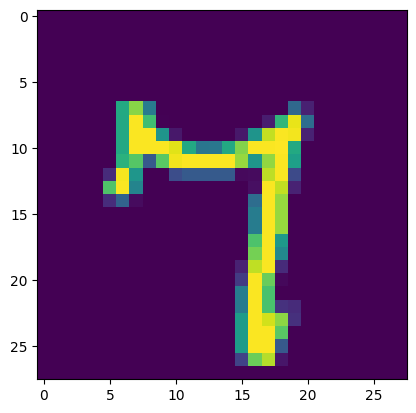

In [5]:
plt.imshow(df.iloc[18567,1:].values.reshape(28,28))

In [6]:
X=df.iloc[:,1:]
Y=df.iloc[:,0]

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=42,test_size=0.2)


In [8]:
X_train.shape

(33600, 784)

In [9]:
from sklearn.neighbors import KNeighborsClassifier

In [10]:
KNN=KNeighborsClassifier()

In [11]:
KNN.fit(X_train,Y_train)

KNeighborsClassifier()

In [12]:
y_pred=KNN.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

In [14]:
accuracy_score(Y_test,y_pred)

0.9648809523809524

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [16]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [17]:
from sklearn.decomposition import PCA 

In [18]:
pca=PCA(n_components=100)

In [19]:
X_trains=pca.fit_transform(X_train)
X_tests=pca.transform(X_test)

In [20]:
KNN.fit(X_trains,Y_train)

KNeighborsClassifier()

In [21]:
y_preds=KNN.predict(X_tests)

In [22]:

accuracy_score(Y_test,y_preds)

0.9544047619047619

In [23]:
for i in range(1,785):
    pca=PCA(n_components=500)
    X_trains=pca.fit_transform(X_train)
    X_tests=pca.transform(X_test)
    KNN=KNeighborsClassifier()
    KNN.fit(X_trains,Y_train)
    y_preds=KNN.predict(X_tests)
    print(accuracy_score(Y_test,y_preds))

0.9410714285714286
0.9410714285714286
0.9410714285714286


KeyboardInterrupt: 

In [27]:
pca =PCA(n_components=3)
X_trains=pca.fit_transform(X_train)
X_tests=pca.transform(X_test)

In [30]:
pca.components_.shape #eigen vecote

(3, 784)

In [35]:
pca.explained_variance_ratio_


array([0.05785192, 0.0414927 , 0.03804239])

In [37]:
pca =PCA(n_components=None)
X_trains=pca.fit_transform(X_train)
X_tests=pca.transform(X_test)

In [40]:
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

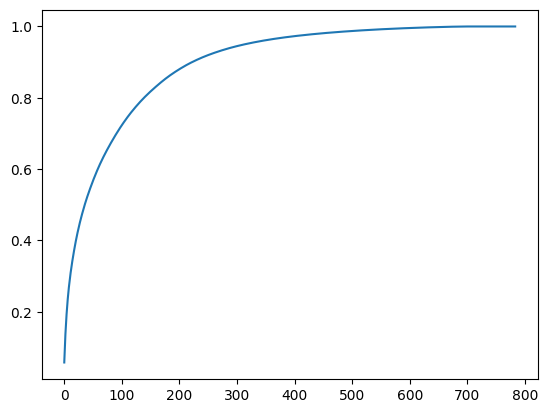

In [41]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [ ]:
e